In [4]:
import pandas as pd
import numpy as np
from prolif import Fingerprint
import seaborn as sns
import matplotlib.pyplot as plt

d:\Coding Projects\AI-in-Drug-Discovery-\god\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\Coding Projects\AI-in-Drug-Discovery-\god\Lib\site-packages\MDAnalysis\topology\tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)


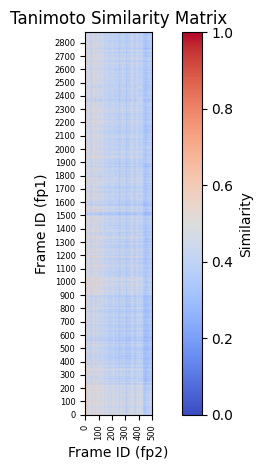

In [8]:
# ───────────────────────── 1. CSV → dataframe ──────────────────────────────
def load_fingerprint(path: str) -> pd.DataFrame:
    """
    Parse the 'Ligand / protein / interaction / Frame / …' CSV into a
    dataframe indexed by frame ID with columns  PROTEIN-INTERACTION.
    """
    raw = pd.read_csv(path, header=None, dtype=str)

    # locate the 'Frame' row
    try:
        frame_row = raw.index[raw.iloc[:, 0] == "Frame"][0]
    except IndexError:
        raise ValueError("'Frame' row not found in {}".format(path))

    data = raw.iloc[frame_row + 1:].reset_index(drop=True)

    frame_ids = pd.to_numeric(data.iloc[:, 0], errors="coerce")
    if frame_ids.isna().any():
        raise ValueError("Non-numeric frame IDs in {}".format(path))

    vals = (
        data.iloc[:, 2:]                       # skip frame-ID & blank column
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0)
            .astype(int)
    )
    n_cols = vals.shape[1]

    proteins     = raw.iloc[1, 2:2 + n_cols].reset_index(drop=True)
    interactions = raw.iloc[2, 2:2 + n_cols].reset_index(drop=True)
    cols = [f"{p}-{i}" if p.strip() and i.strip() else f"Unk_{k}"
            for k, (p, i) in enumerate(zip(proteins, interactions))]

    if pd.Series(cols).duplicated().any():
        dups = pd.Series(cols)[pd.Series(cols).duplicated()].tolist()
        raise ValueError(f"Duplicate feature columns in {path}: {dups}")

    vals.columns = cols
    vals.index   = frame_ids.astype(int)
    return vals


# ───────────────────── 2. align *columns* only ──────────────────────────────
def align_columns(df1: pd.DataFrame, df2: pd.DataFrame):
    """Return two tables that share the union of bit columns (rows unchanged)."""
    all_cols = sorted(set(df1.columns) | set(df2.columns))
    return (df1.reindex(columns=all_cols, fill_value=0),
            df2.reindex(columns=all_cols, fill_value=0))


# ─────────────────────── 3. Tanimoto matrix ────────────────────────────────
def tanimoto(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    a, b = df1.astype(bool).to_numpy(int), df2.astype(bool).to_numpy(int)
    inter  = a @ b.T
    denom  = a.sum(1)[:, None] + b.sum(1)[None, :] - inter
    mat    = np.where(denom == 0, 1.0, inter / denom)        # Ø vs Ø → 1
    return pd.DataFrame(mat, index=df1.index, columns=df2.index)


# ─────────────────────────── 4. plot heat-map ──────────────────────────────
def plot_tanimoto(matrix: pd.DataFrame, tick_step: int = 100):
    """
    Plot a Tanimoto similarity heatmap using matplotlib only,
    with readable frame ID labels at specified intervals.
    """
    fig, ax = plt.subplots()
    cax = ax.imshow(matrix.values, cmap="coolwarm", vmin=0, vmax=1, origin='lower')

    # Define ticks at regular intervals
    xticks = range(0, matrix.shape[1], tick_step)
    yticks = range(0, matrix.shape[0], tick_step)

    ax.set_xticks(xticks)
    ax.set_xticklabels([matrix.columns[i] for i in xticks], rotation=90, fontsize=6)

    ax.set_yticks(yticks)
    ax.set_yticklabels([matrix.index[i] for i in yticks], fontsize=6)

    ax.set_xlabel("Frame ID (fp2)")
    ax.set_ylabel("Frame ID (fp1)")
    ax.set_title("Tanimoto Similarity Matrix")

    fig.colorbar(cax, ax=ax, label='Similarity')
    plt.tight_layout()
    plt.show()


# ─────────────────────────── 5. analysis  ───────────────────────────────────────
FP1_PATH = "Data/New/fp_comp_dataframe_COC.csv"   # ≈ 2 800 frames
FP2_PATH = "Data/Original/fp_comp_dataframe_COC.csv"                     # ≈   700 frames

fp1 = load_fingerprint(FP1_PATH)
fp2 = load_fingerprint(FP2_PATH)

fp1, fp2   = align_columns(fp1, fp2)     # rows untouched
tan_df     = tanimoto(fp1, fp2)          # shape (2800, 700)

# 2️⃣  show the rectangular heat-map
plot_tanimoto(tan_df)  # adjust tick_step if needed

In [9]:
FP1_PATH = "Data/New/fp_comp_dataframe_COC.csv"   # ≈ 2 800 frames
FP2_PATH = "Data/New/processed/cleaned_MPH.csv"                     # ≈   700 frames

fp1 = load_fingerprint(FP1_PATH)
fp2 = load_fingerprint(FP2_PATH)

fp1, fp2   = align_columns(fp1, fp2)     # rows untouched
tan_df     = tanimoto(fp1, fp2)          # shape (2800, 700)

# 2️⃣  show the rectangular heat-map
plot_tanimoto(tan_df)  # adjust tick_step if needed

ValueError: 'Frame' row not found in Data/New/processed/cleaned_MPH.csv

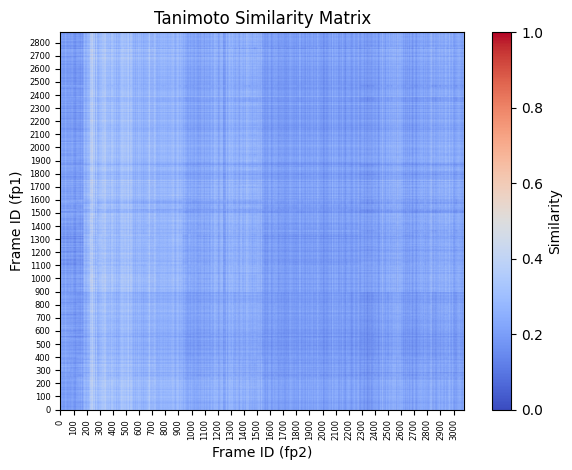

In [23]:
FP1_PATH = "fp_comp_dataframe_COC.csv"   # ≈ 2 800 frames
FP2_PATH = "fp_comp_dataframe_BZT.csv"                     # ≈   700 frames

fp1 = load_fingerprint(FP1_PATH)
fp2 = load_fingerprint(FP2_PATH)

fp1, fp2   = align_columns(fp1, fp2)     # rows untouched
tan_df     = tanimoto(fp1, fp2)          # shape (2800, 700)

# 2️⃣  show the rectangular heat-map
plot_tanimoto(tan_df)  # adjust tick_step if needed

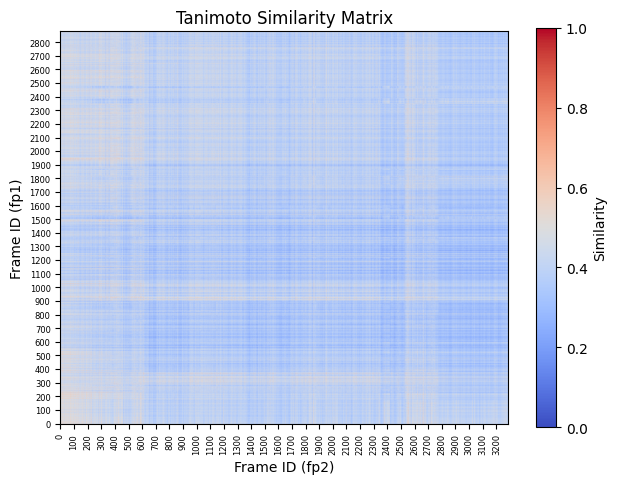

In [24]:
FP1_PATH = "fp_comp_dataframe_COC.csv"   # ≈ 2 800 frames
FP2_PATH = "fp_comp_dataframe_DOP.csv"                     # ≈   700 frames

fp1 = load_fingerprint(FP1_PATH)
fp2 = load_fingerprint(FP2_PATH)

fp1, fp2   = align_columns(fp1, fp2)     # rows untouched
tan_df     = tanimoto(fp1, fp2)          # shape (2800, 700)

# 2️⃣  show the rectangular heat-map
plot_tanimoto(tan_df)  # adjust tick_step if needed

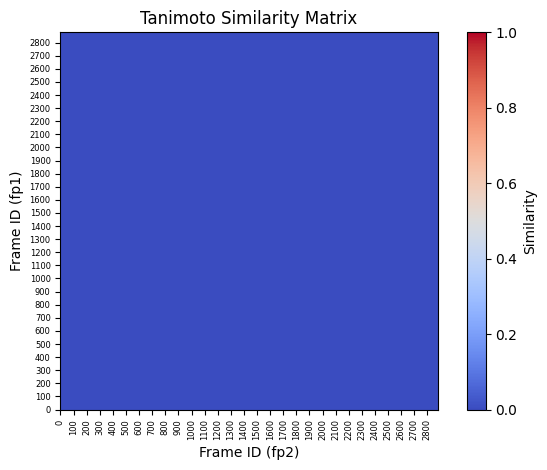

In [30]:
FP1_PATH = "fp_comp_dataframe_COC.csv"  
FP2_PATH = "fp_comp_dataframe_COC_2.csv"         

fp1 = load_fingerprint(FP1_PATH)
fp2 = load_fingerprint(FP2_PATH)

fp1, fp2   = align_columns(fp1, fp2)     # rows untouched
tan_df     = tanimoto(fp1, fp2)          # shape (2800, 700)

# 2️⃣  show the rectangular heat-map
plot_tanimoto(tan_df)  # adjust tick_step if needed

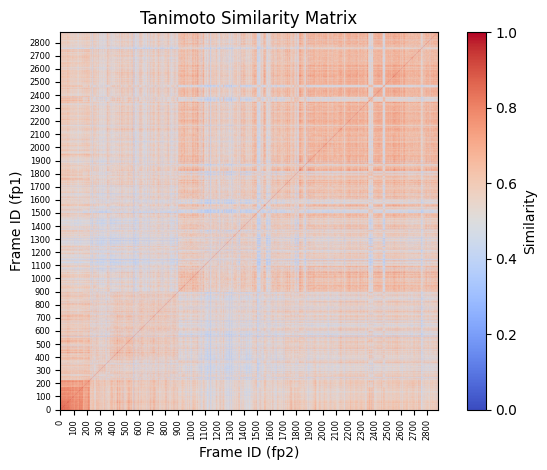

In [31]:
FP1_PATH = "fp_comp_dataframe_COC.csv"  
FP2_PATH = "fp_comp_dataframe_COC.csv"         

fp1 = load_fingerprint(FP1_PATH)
fp2 = load_fingerprint(FP2_PATH)

fp1, fp2   = align_columns(fp1, fp2)     # rows untouched
tan_df     = tanimoto(fp1, fp2)          # shape (2800, 700)

# 2️⃣  show the rectangular heat-map
plot_tanimoto(tan_df)  # adjust tick_step if needed

In [ ]:
FP1_PATH = "fp_comp_dataframe_COC.csv"  
FP2_PATH = "COC.csv"         

fp1 = load_fingerprint(FP1_PATH)
fp2 = load_fingerprint(FP2_PATH)

fp1, fp2   = align_columns(fp1, fp2)     # rows untouched
tan_df     = tanimoto(fp1, fp2)          # shape (2800, 700)

# 2️⃣  show the rectangular heat-map
plot_tanimoto(tan_df)  # adjust tick_step if needed